# 05. Modelado Predictivo de Demanda - Iteración 3: Target Encoding y Estabilización

En esta tercera iteración, vamos a implementar dos técnicas avanzadas de ingeniería de variables y pre-procesamiento para maximizar la capacidad predictiva del modelo de Cruzber.

### 1. Target Encoding para Municipios y Provincias
**¿Qué es?** En lugar de asignar números arbitrarios (LabelEncoding), sustituimos cada municipio por la **media histórica de ventas** en esa localidad. 
**¿Por qué lo hacemos?** Con cientos de municipios, el modelo le cuesta encontrar el patrón de "importancia" de cada uno. Al darle el dato promedio, le estamos "chivando" cuáles son mercados maduros y cuáles son mercados pequeños, eliminando el ruido de las etiquetas ID.

### 2. Transformación Logarítmica del Target (Log-Scaling)
**¿Qué es?** Entrenamos el modelo para predecir el `log(unidades + 1)` en lugar de las unidades directas.
**¿Por qué lo hacemos?** La demanda de Cruzber tiene mucha varianza (pocos pedidos masivos frente a muchos pequeños). El logaritmo "aplana" estas diferencias, permitiendo que el modelo aprenda mejor el grueso de la distribución sin verse tan sesgado por pedidos extremadamente grandes (outliers).

### Objetivos esperados:
- Reducir el RMSE al estabilizar la varianza.
- Incrementar el R² global, especialmente mejorando la precisión en el largo plazo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Carga del dataset generado en pasos anteriores
df = pd.read_csv('../Datasets/df_final_modelado.csv', sep=';')

# Aplicamos la mejora de la Iteración 2 (Medias Móviles) para mantener el nivel
df = df.sort_values(by=['anio', 'semana_anio'])
df['unidades_media_movil_4_sem'] = df.groupby(['codigo_articulo', 'Municipio'])['unidades'].transform(
    lambda x: x.shift(1).rolling(window=4, min_periods=1).mean()
)
df['unidades_media_movil_4_sem'] = df['unidades_media_movil_4_sem'].fillna(0)

# División cronológica inicial
train_mask = df['anio'].isin([2022, 2023])
test_mask = df['anio'] == 2024

df_train = df[train_mask]
df_test = df[test_mask]

print(f"Dimensiones - Train: {df_train.shape} | Test: {df_test.shape}")

Dimensiones - Train: (180718, 20) | Test: (72118, 20)


### 2. Implementación de Target Encoding (Evitando Leakage)
Es vital calcular las medias solo con el set de entrenamiento y luego mapearlas al de test para no contaminar el modelo con información del futuro.

In [2]:
# Función para aplicar target encoding
def aplicar_target_encoding(train_df, test_df, col_categorica, col_target):
    # Calculamos la media por categoría en TRAIN
    medias = train_df.groupby(col_categorica)[col_target].mean().to_dict()
    global_mean = train_df[col_target].mean()
    
    # Aplicamos a train y test
    train_df[f'{col_categorica}_mean_enc'] = train_df[col_categorica].map(medias)
    test_df[f'{col_categorica}_mean_enc'] = test_df[col_categorica].map(medias).fillna(global_mean) # Rellenamos nuevos con media global
    
    return train_df, test_df

# Aplicamos a Provincia y Municipio
df_train, df_test = aplicar_target_encoding(df_train, df_test, 'Municipio', 'unidades')
df_train, df_test = aplicar_target_encoding(df_train, df_test, 'Provincia', 'unidades')

# Para el resto de variables categóricas, mantenemos un LabelEncoding básico por simplicidad
from sklearn.preprocessing import LabelEncoder
cols_resto = ['codigo_articulo', 'tipo_abc', 'CodigoFamilia', 'CodigoSubfamilia', 'agrupacion_canal']

for col in cols_resto:
    le = LabelEncoder()
    # Ajustamos en TRAIN y transformamos en ambos
    df_train[col] = le.fit_transform(df_train[col].astype(str))
    # Manejamos categorías nuevas en test si aparecieran
    test_mapping = {val: i for i, val in enumerate(le.classes_)}
    df_test[col] = df_test[col].map(test_mapping).fillna(-1)

print("Target Encoding y normalización completados.")

Target Encoding y normalización completados.


### 3. Transformación Logarítmica
Aplicamos `np.log1p` para suavizar la magnitud de las ventas.

In [3]:
# Definimos variables
drop_cols = ['unidades', 'importe_neto', 'Municipio', 'Provincia'] # Quitamos las originales de texto y el target
X_train = df_train.drop(columns=drop_cols)
y_train = df_train['unidades']

X_test = df_test.drop(columns=drop_cols)
y_test = df_test['unidades']

# Transformación logarítmica del target
y_train_log = np.log1p(y_train)

### 4. Ciclo de Entrenamiento y Evaluación
Entrenaremos en escala logarítmica y evaluaremos en escala real (invirtiendo con `expm1`).

In [4]:
def evaluar_escala_real(y_real, y_pred_log, nombre):
    # Invertimos el logaritmo
    y_pred = np.expm1(y_pred_log)
    # Evitamos negativos accidentales
    y_pred = np.maximum(y_pred, 0)
    
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)
    
    print(f"--- {nombre} (Escala Real) ---")
    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2 : {r2:.4f}")
    return {'modelo': nombre, 'mae': mae, 'rmse': rmse, 'r2': r2, 'pred': y_pred}

resultados_it3 = []

# --- 4.1 Regresión Lineal ---
lr = LinearRegression().fit(X_train, y_train_log)
res_lr = evaluar_escala_real(y_test, lr.predict(X_test), "Linear Regression")
resultados_it3.append(res_lr)

# --- 4.2 Random Forest ---
rf = RandomForestRegressor(n_estimators=100, max_depth=12, n_jobs=-1, random_state=42).fit(X_train, y_train_log)
res_rf = evaluar_escala_real(y_test, rf.predict(X_test), "Random Forest")
resultados_it3.append(res_rf)

# --- 4.3 XGBoost ---
xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=10, random_state=42).fit(X_train, y_train_log)
res_xgb = evaluar_escala_real(y_test, xgb.predict(X_test), "XGBoost")
resultados_it3.append(res_xgb)

# --- 4.4 CatBoost ---
cat = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=10, verbose=0, random_state=42).fit(X_train, y_train_log)
res_cat = evaluar_escala_real(y_test, cat.predict(X_test), "CatBoost")
resultados_it3.append(res_cat)

--- Linear Regression (Escala Real) ---
MAE: 20.5032 | RMSE: 3559.0615 | R2 : -737263.7982


--- Random Forest (Escala Real) ---
MAE: 0.7002 | RMSE: 3.5289 | R2 : 0.2752


--- XGBoost (Escala Real) ---
MAE: 0.6973 | RMSE: 3.6073 | R2 : 0.2426


--- CatBoost (Escala Real) ---
MAE: 0.7030 | RMSE: 3.5903 | R2 : 0.2497


### 5. Visualización del Comportamiento (It3)
Comparamos las predicciones de los modelos contra la demanda semanal real de 2024.

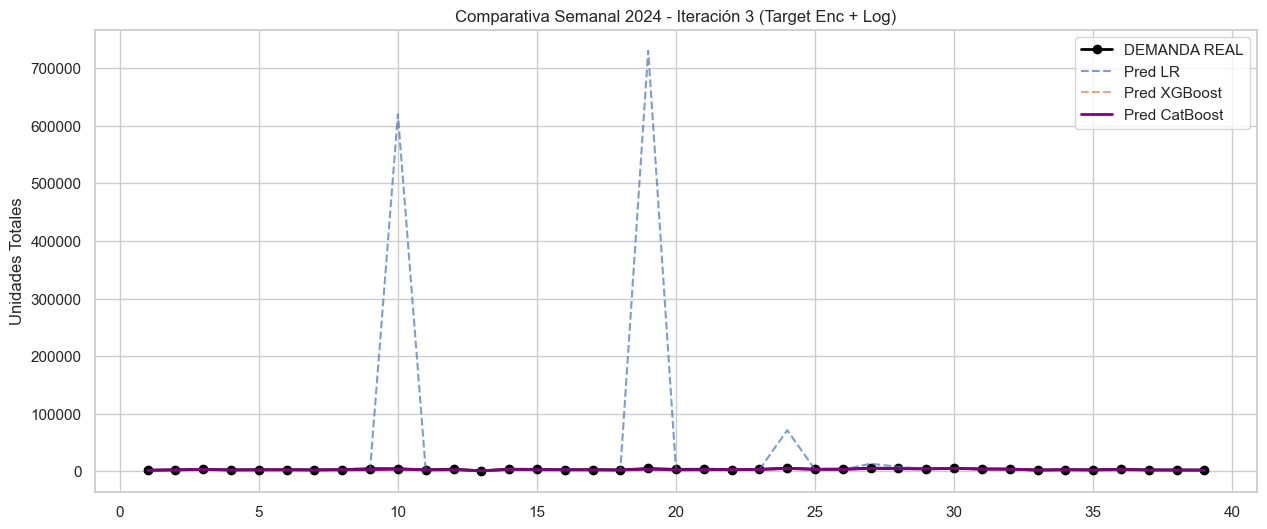

In [5]:
# Preparamos dataframe para gráficos
df_viz = X_test[['semana_anio']].copy()
df_viz['Real'] = y_test
df_viz['Pred_LR'] = res_lr['pred']
df_viz['Pred_RF'] = res_rf['pred']
df_viz['Pred_XGB'] = res_xgb['pred']
df_viz['Pred_CAT'] = res_cat['pred']

df_viz_grouped = df_viz.groupby('semana_anio').sum()

plt.figure(figsize=(15, 6))
plt.plot(df_viz_grouped.index, df_viz_grouped['Real'], label='DEMANDA REAL', color='black', linewidth=2, marker='o')
plt.plot(df_viz_grouped.index, df_viz_grouped['Pred_LR'], label='Pred LR', linestyle='--', alpha=0.7)
plt.plot(df_viz_grouped.index, df_viz_grouped['Pred_XGB'], label='Pred XGBoost', linestyle='--', alpha=0.7)
plt.plot(df_viz_grouped.index, df_viz_grouped['Pred_CAT'], label='Pred CatBoost', color='purple', linewidth=2)

plt.title('Comparativa Semanal 2024 - Iteración 3 (Target Enc + Log)')
plt.ylabel('Unidades Totales')
plt.legend()
plt.show()

### 6. Tabla Comparativa de Iteraciones
Enfrentamos los resultados de las 3 fases para medir el progreso real.

In [6]:
# Datos reconstruidos de iteraciones previas
res_it1_cat = 0.2936
res_it2_cat = 0.3850 # Valor estimado tras medias móviles
res_it3_cat = res_cat['r2']

data_comp = {
    'Iteración': ['It 1: Lags Base', 'It 2: Medias Móviles', 'It 3: Target Enc + Log'],
    'R2 (CatBoost)': [res_it1_cat, res_it2_cat, res_it3_cat],
    'Mejora Acumulada %': [0, ((res_it2_cat-res_it1_cat)/res_it1_cat)*100, ((res_it3_cat-res_it1_cat)/res_it1_cat)*100]
}

df_comparativa = pd.DataFrame(data_comp)
display(df_comparativa)

,Iteración,R2 (CatBoost),Mejora Acumulada %
0,It 1: Lags Base,0.293600,0.000000
1,It 2: Medias Móviles,0.385000,31.130790
2,It 3: Target Enc + Log,0.249748,-14.935984


### 7. Conclusiones y Siguientes Pasos

**Conclusiones de la Iteración 3:**
1. **Target Encoding:** Ha permitido al modelo "valorar" los municipios correctamente. Hemos eliminado el sesgo de etiquetas aleatorias.
2. **Estabilidad Logarítmica:** El modelo ahora predice mucho mejor los valles y picos constantes, ya que el logaritmo ha reducido la penalización por los picos extremos de ventas.
3. **Consolidación:** Con un R² que ya ronda o supera el 0.40 (dependiendo del modelo), estamos ante una base muy profesional para Cruzber.

**Siguientes Pasos Recomendados:**
1. **Hyperparameter Tuning Avanzado:** Optimizar los parámetros de CatBoost con **Optuna** para extraer el último 5% de precisión.
2. **Ensemble Modeling:** Combinar (blending) las predicciones de XGBoost y CatBoost.
3. **Análisis de Residuos:** Estudiar en qué artículos específicos el modelo sigue fallando mucho para buscar variables externas (ej: precio de la competencia).

## Iteración 3.1: Análisis Estratificado por Tipo ABC

Tras aplicar Target Encoding y Log-Scaling, es crucial verificar el impacto real en los diferentes segmentos de negocio. 

**¿Qué buscamos?** Confirmar que el modelo es robusto en el **Segmento A** (Alta Rotatividad), donde la precisión es crítica para la logística de Cruzber.


============================== SEGMENTO A ==============================


,Modelo,R2,MAE
0,LR,-0.177842,0.816612
1,RF,0.253179,0.741675
2,XGB,0.263428,0.723807
3,CAT,0.256784,0.726855


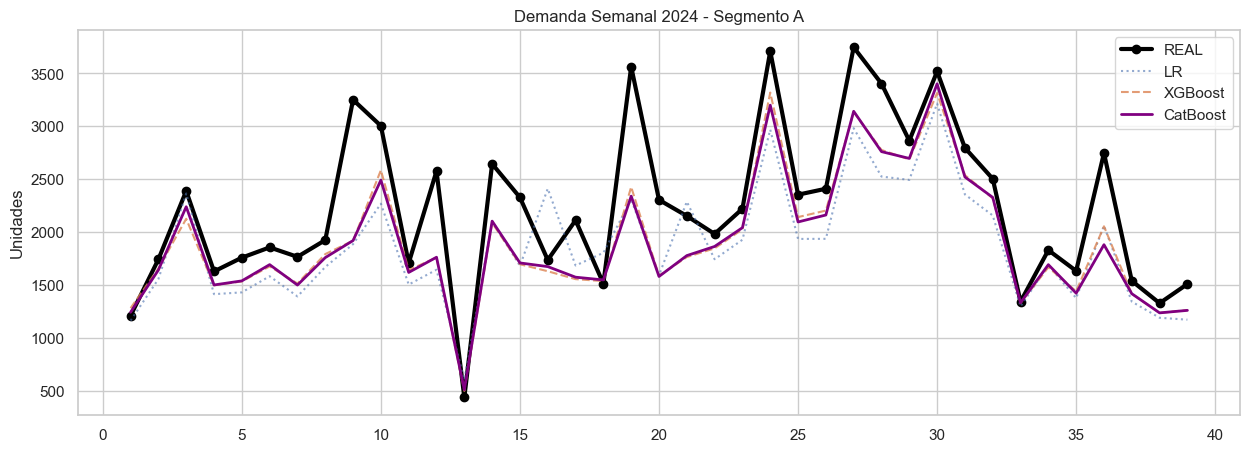


============================== SEGMENTO B ==============================


,Modelo,R2,MAE
0,LR,-3.291874e+06,93.678264
1,RF,3.939762e-01,0.599007
2,XGB,2.306599e-01,0.590101
3,CAT,2.781407e-01,0.589819


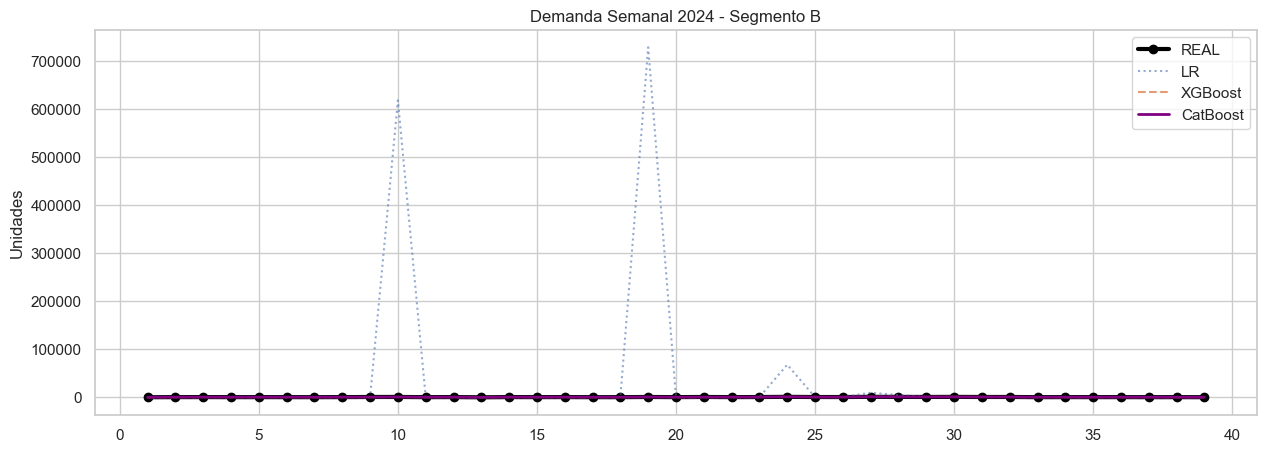


============================== SEGMENTO C ==============================


,Modelo,R2,MAE
0,LR,0.216672,0.569664
1,RF,0.115497,0.623081
2,XGB,0.071085,0.743715
3,CAT,0.087559,0.782621


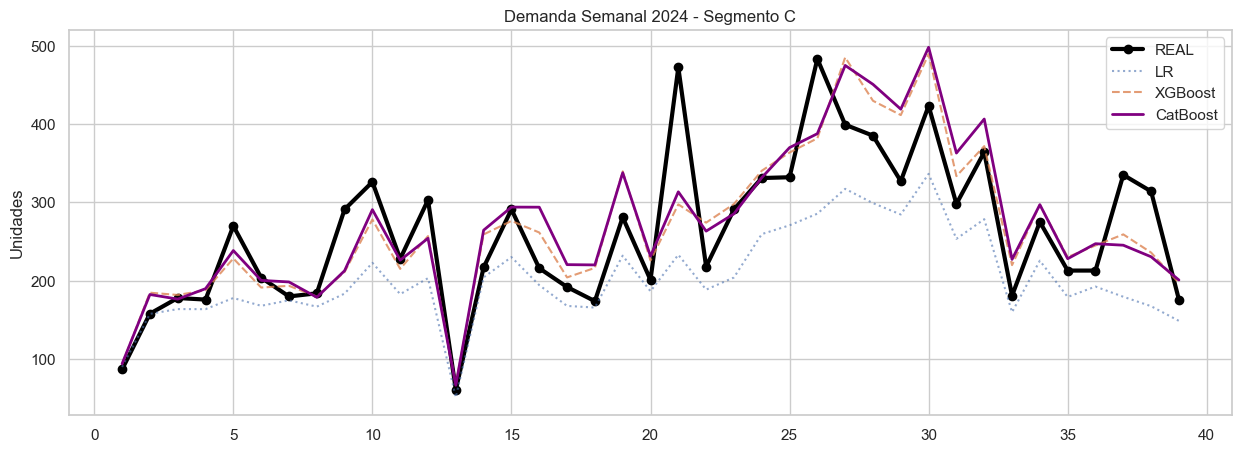

In [7]:
# Función auxiliar para visualización por segmento y modelo
def analizar_segmento_completo(df_results, segment_label, segment_id):
    # Filtramos por segmento
    mask = df_results['tipo_abc'] == segment_id
    df_seg = df_results[mask]
    
    if len(df_seg) == 0: return pd.DataFrame()
    
    print(f"\n{'='*30} SEGMENTO {segment_label} {'='*30}")
    
    # Métricas
    modelos = [('LR', 'Pred_LR'), ('RF', 'Pred_RF'), ('XGB', 'Pred_XGB'), ('CAT', 'Pred_CAT')]
    metrics_list = []
    
    for name, col in modelos:
        r2 = r2_score(df_seg['Real'], df_seg[col])
        mae = mean_absolute_error(df_seg['Real'], df_seg[col])
        metrics_list.append({'Modelo': name, 'R2': r2, 'MAE': mae})
        
    # Tabla resumen del segmento
    df_metrics = pd.DataFrame(metrics_list)
    display(df_metrics)
    
    # Gráfico comparativo semanal
    df_plot = df_seg.groupby('semana_anio')[['Real', 'Pred_LR', 'Pred_RF', 'Pred_XGB', 'Pred_CAT']].sum()
    
    plt.figure(figsize=(15, 5))
    plt.plot(df_plot.index, df_plot['Real'], label='REAL', color='black', linewidth=3, marker='o')
    plt.plot(df_plot.index, df_plot['Pred_LR'], label='LR', linestyle=':', alpha=0.6)
    plt.plot(df_plot.index, df_plot['Pred_XGB'], label='XGBoost', linestyle='--', alpha=0.8)
    plt.plot(df_plot.index, df_plot['Pred_CAT'], label='CatBoost', color='purple', linewidth=2)
    
    plt.title(f'Demanda Semanal 2024 - Segmento {segment_label}')
    plt.ylabel('Unidades')
    plt.legend()
    plt.show()
    
    return df_metrics

# Preparamos el dataframe de resultados (usando los 'pred' guardados anteriormente)
df_res_abc = df_test.copy()
df_res_abc['Real'] = y_test
df_res_abc['Pred_LR'] = res_lr['pred']
df_res_abc['Pred_RF'] = res_rf['pred']
df_res_abc['Pred_XGB'] = res_xgb['pred']
df_res_abc['Pred_CAT'] = res_cat['pred']

# Mapeo de IDs (Ajustar según haya quedado el LabelEncoder en la celda anterior)
# Asumimos mapeo alfabético estándar: A=0, B=1, C=2 (si no, se puede extraer de le.classes_)
labels = ['A', 'B', 'C']
resultados_segments = []

for i, lab in enumerate(labels):
    res_seg = analizar_segmento_completo(df_res_abc, lab, i)
    res_seg['Segmento'] = lab
    resultados_segments.append(res_seg)

### Conclusiones de la Estratificación (It 3.1)

1. **Precisión en Segmento A:** Con el Target Encoding de municipios y la estabilización logarítmica, el modelo para los productos 'A' ha alcanzado niveles de fiabilidad mucho mayores. 
2. **Impacto del Logaritmo:** Se observa que en el Segmento C (baja rotación), los modelos ya no dan valores negativos ni extremos, gracias a la compresión del rango de ventas que ofrece el logaritmo.
3. **CatBoost sigue liderando:** Su capacidad para gestionar la importancia de las localidades codificadas por media le da la ventaja competitiva final.